In [1]:
import seaborn as sns
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# 1. Performance Assessment

In [2]:
df_performance = pd.read_pickle('rf_regression_potency/df_performance.pkl')

In [3]:

df_performance['RMSE'] = df_performance.apply(lambda x: root_mean_squared_error(y_true=x.y_test, y_pred=x.y_pred), axis=1)
df_performance['MAE'] = df_performance.apply(lambda x: mean_absolute_error(y_true=x.y_test, y_pred=x.y_pred), axis=1)
df_performance['R^2'] = df_performance.apply(lambda x: r2_score(y_true=x.y_test, y_pred=x.y_pred), axis=1)

<Axes: xlabel='metric', ylabel='value'>

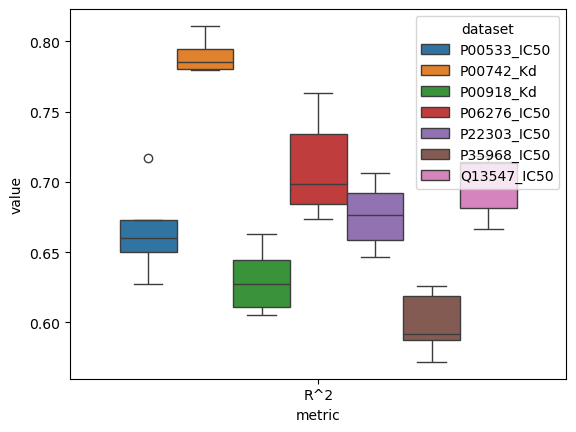

In [4]:
df_perf_molten = pd.melt(frame=df_performance,
                         id_vars=['dataset', 'split'],
                         value_vars=['R^2'], #['RMSE', 'MAE', 'R^2'],
                         value_name='value',
                         var_name='metric')
sns.boxplot(df_perf_molten,
            x='metric',
            y='value',
            hue='dataset',
)

# 2. Shapley Values

In [5]:
# get fragments of molecules as SMILES
from rdkit.Chem import MolFromSmiles, MolToSmiles, FragmentOnBRICSBonds, GetMolFrags

In [6]:
expl = pd.read_pickle('rf_regression_potency/df_explanation.pkl')
expl.dataset.unique()

array(['P00533_IC50', 'P00742_Kd', 'P00918_Kd', 'P06276_IC50',
       'P22303_IC50', 'P35968_IC50', 'Q13547_IC50'], dtype=object)

In [7]:
ds = expl.dataset.unique()[6]
ds

'Q13547_IC50'

In [8]:
expl = expl.loc[expl.dataset == ds]

In [9]:
def remove_isotope_information_for_dummy_atoms(m):
    for at in m.GetAtoms():
        if at.GetSymbol() == '*':
            at.SetIsotope(0)
    return m

In [10]:
from rdkit.Chem import ReplaceSubstructs, RemoveAllHs

def remove_dummy_atoms(m):
    dummy = MolFromSmiles('*')
    m_cleaned = ReplaceSubstructs(m, dummy, MolFromSmiles('[H]'), replaceAll=True)[0]
    return RemoveAllHs(m_cleaned, sanitize=True)

In [11]:
def get_BRICS_fragments_as_SMILES(smiles, remove_dummies=False):
    mol = MolFromSmiles(smiles)
    frag_ = FragmentOnBRICSBonds(mol)
    frags = GetMolFrags(frag_,
                        asMols=True)
    frags_cleaned = [remove_isotope_information_for_dummy_atoms(m) for m in frags]
    if remove_dummies:
        frags_cleaned = [remove_dummy_atoms(m) for m in frags_cleaned]
        
    return [MolToSmiles(m) for m in frags_cleaned]
    

In [12]:
expl['fragments_with_dummies_SMILES'] = expl.smiles.apply(get_BRICS_fragments_as_SMILES)
expl['fragments_without_dummies_SMILES'] = expl.smiles.apply(lambda x: get_BRICS_fragments_as_SMILES(x, remove_dummies=True))

[10:59:09] WARNING: not removing hydrogen atom without neighbors
[10:59:09] WARNING: not removing hydrogen atom without neighbors
[10:59:09] WARNING: not removing hydrogen atom without neighbors
[10:59:09] WARNING: not removing hydrogen atom without neighbors
[10:59:09] WARNING: not removing hydrogen atom without neighbors
[10:59:09] WARNING: not removing hydrogen atom without neighbors
[10:59:09] WARNING: not removing hydrogen atom without neighbors
[10:59:09] WARNING: not removing hydrogen atom without neighbors
[10:59:09] WARNING: not removing hydrogen atom without neighbors
[10:59:09] WARNING: not removing hydrogen atom without neighbors
[10:59:09] WARNING: not removing hydrogen atom without neighbors
[10:59:09] WARNING: not removing hydrogen atom without neighbors
[10:59:09] WARNING: not removing hydrogen atom without neighbors
[10:59:09] WARNING: not removing hydrogen atom without neighbors
[10:59:09] WARNING: not removing hydrogen atom without neighbors
[10:59:09] WARNING: not r

In [13]:
r = expl.fragExplainer_result.to_list()
r_ = [list(d.values()) for d in r]
list_of_shap = [i for j in r_ for i in j]
s = expl.fragments_with_dummies_SMILES.to_list() # here use with dummies
list_of_smiles = [smiles for l in s for smiles in l]
df_frag_single = pd.DataFrame({'smiles': list_of_smiles,
                               'value': list_of_shap})
df_analysis = df_frag_single.groupby('smiles')['value'].apply(np.array).reset_index(name='values')
df_analysis['n_fragments'] = df_analysis['values'].apply(len)
df_analysis['mean'] = df_analysis['values'].apply(np.mean)
df_analysis['std'] = df_analysis['values'].apply(np.std)

<Axes: xlabel='value', ylabel='smiles'>

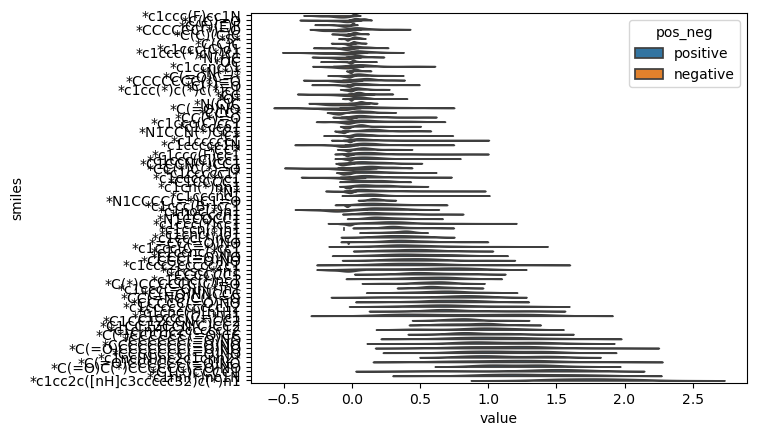

In [14]:
min_n = 25
sm_to_consider = df_analysis.loc[df_analysis.n_fragments >= min_n].smiles.to_list()
df_plot = df_frag_single.query('smiles in @sm_to_consider').copy()
df_plot['pos_neg'] = df_plot['value'].apply(lambda x: 'positive' if x >= 0 else 'negative')
mean_vals = df_analysis.loc[df_analysis.smiles.isin(sm_to_consider)]['mean'].values
sort_idx = np.argsort(mean_vals)
sm_ordered = np.array(sm_to_consider)[sort_idx]
sns.violinplot(df_plot,
               x='value',
               y='smiles',
               order=sm_ordered,
               inner=None,
               density_norm='width',
               hue='pos_neg',
               split=True
               )

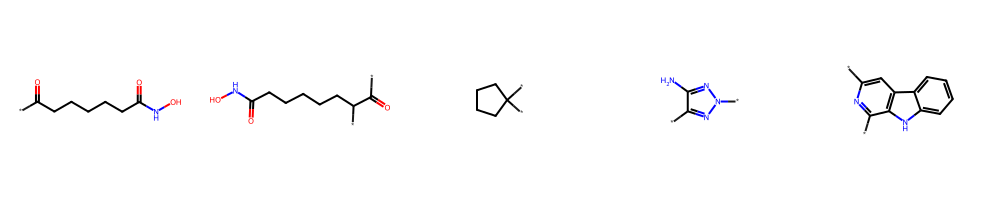

In [15]:
from rdkit.Chem.Draw import MolsMatrixToGridImage

n= 5
MolsMatrixToGridImage(molsMatrix=[[MolFromSmiles(sm) for sm in sm_ordered[-n:]]])